In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.19.0
Keras version: 3.13.2


In [22]:
data = np.array([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])
inputs = data[:, :2]
#inputs[inputs == 0] = -1
outputs = data[:, 2:]

In [23]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((2,)),
    tf.keras.layers.Dense(5, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1.0, momentum=0.0),
              loss=tf.keras.losses.mse,
              metrics=[tf.keras.metrics.binary_accuracy])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
hist = model.fit(inputs, outputs, batch_size=4, epochs=1000, verbose=2)

Epoch 1/1000
1/1 - 0s - 379ms/step - binary_accuracy: 0.5000 - loss: 0.2566
Epoch 2/1000
1/1 - 0s - 44ms/step - binary_accuracy: 0.5000 - loss: 0.2525
Epoch 3/1000
1/1 - 0s - 42ms/step - binary_accuracy: 0.5000 - loss: 0.2504
Epoch 4/1000
1/1 - 0s - 44ms/step - binary_accuracy: 0.7500 - loss: 0.2493
Epoch 5/1000
1/1 - 0s - 45ms/step - binary_accuracy: 0.7500 - loss: 0.2487
Epoch 6/1000
1/1 - 0s - 42ms/step - binary_accuracy: 0.7500 - loss: 0.2484
Epoch 7/1000
1/1 - 0s - 45ms/step - binary_accuracy: 0.7500 - loss: 0.2482
Epoch 8/1000
1/1 - 0s - 41ms/step - binary_accuracy: 0.7500 - loss: 0.2481
Epoch 9/1000
1/1 - 0s - 60ms/step - binary_accuracy: 0.5000 - loss: 0.2480
Epoch 10/1000
1/1 - 0s - 64ms/step - binary_accuracy: 0.5000 - loss: 0.2479
Epoch 11/1000
1/1 - 0s - 40ms/step - binary_accuracy: 0.5000 - loss: 0.2479
Epoch 12/1000
1/1 - 0s - 40ms/step - binary_accuracy: 0.5000 - loss: 0.2478
Epoch 13/1000
1/1 - 0s - 60ms/step - binary_accuracy: 0.5000 - loss: 0.2477
Epoch 14/1000
1/1 - 

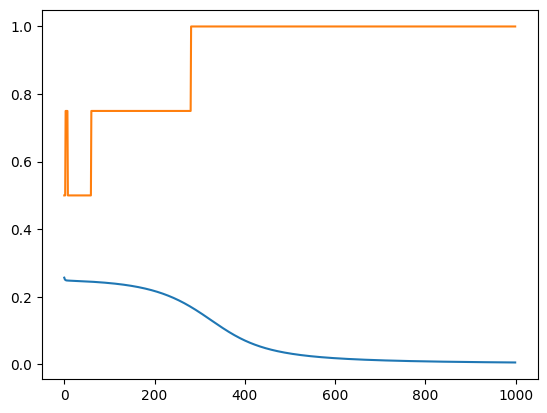

In [25]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['binary_accuracy'])
plt.show()

In [26]:
res = model.evaluate(inputs, outputs, batch_size=4)
print(res)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - binary_accuracy: 1.0000 - loss: 0.0056
[0.005555562674999237, 1.0]


In [27]:
out = model.predict(inputs)
for x, t, y in zip(inputs, outputs, out):
    print(x, '->', t, '=>', y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[0 0] -> [0] => [0.04568144]
[0 1] -> [1] => [0.92562205]
[1 0] -> [1] => [0.92371154]
[1 1] -> [0] => [0.09372006]
